In [19]:
import spacy
from textblob import TextBlob
_project_path = "/Users/victoriatorresrodriguez/Desktop/APP/"

In [6]:
import json

with open(_project_path + "raw_session_diaries.json") as json_file:
    session_diaries = json.load(json_file)

In [7]:
import tiktoken

session_diaries = [entry["text"] for entry in session_diaries]
print(len(session_diaries))

encoder = tiktoken.get_encoding("o200k_base")
tokens_per_document = [len(encoder.encode(doc)) for doc in session_diaries]

11051


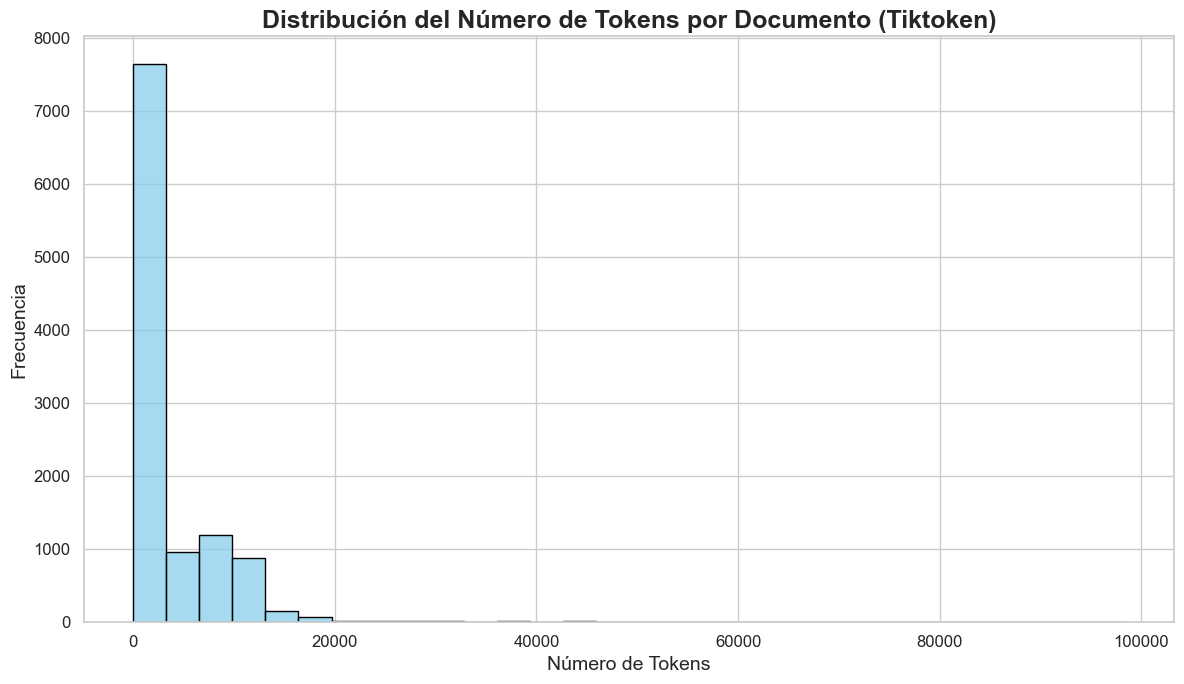

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Establecer tema moderno
sns.set_theme(style="whitegrid")  # Reemplaza al antiguo sns.set()

# Crear el gráfico
plt.figure(figsize=(12, 7))
sns.histplot(tokens_per_document, bins=30, edgecolor='black', color='skyblue')

# Mejoras visuales
plt.title('Distribución del Número de Tokens por Documento (Tiktoken)', fontsize=18, weight='bold')
plt.xlabel('Número de Tokens', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


In [16]:
from collections import Counter
import spacy
spacy.cli.download("es_core_news_sm")
nlp = spacy.load("es_core_news_sm")


def preprocess_text(session_diaries):
    words = []
    for i, session in enumerate(session_diaries):
        print(f"Procesando documento {i + 1}/{len(session_diaries)}")
        doc = nlp(session)  # Procesar el texto con spaCy
        tokens = [
            token.lemma_.lower() for token in doc  # Usar el lema
            if not token.is_stop  # Excluir stopwords
               and not token.is_punct  # Excluir puntuación
               and not token.like_num  # Excluir números
               and len(token.lemma_) > 2  # Excluir palabras muy cortas
        ]
        words.extend(tokens)
    return words


cleaned_words = preprocess_text(session_diaries)
frequencies = Counter(cleaned_words)
# Obtener las N palabras más frecuentes
N = 20
most_common_words = frequencies.most_common(N)
words, counts = zip(*most_common_words)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 37.9 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Procesando documento 1/11051
Procesando documento 2/11051
Procesando documento 3/11051
Procesando documento 4/11051
Procesando documento 5/11051
Procesando documento 6/11051
Procesando documento 7/11051
Procesando documento 8/11051
Procesando documento 9/11051
Procesando documento 10/11051
Procesando documento 11/11051
Procesando documento 12/11051
Procesando documento 13/11051
Procesando documento 14/11051
Procesando documento 15/11051
Procesando documento 16/11051
Procesando documento 17/11051
Procesando documento 18/11051
Procesando documento 19/11051
Procesando documento 20/11051
Procesando documento 21/11051
Procesando documento 22/11051
Procesando documento 23/11051
Procesando documento 24/11051
Procesando documento 25/11051
Procesando documento 26/11051
Procesando documento 27/11051
Procesando documento 28/11051
Procesando documento 29/11051
Procesando documento 30/11051
Procesando documento 31/11051
Procesando documento 32/11051
Procesando documento 33/11051
Procesando document

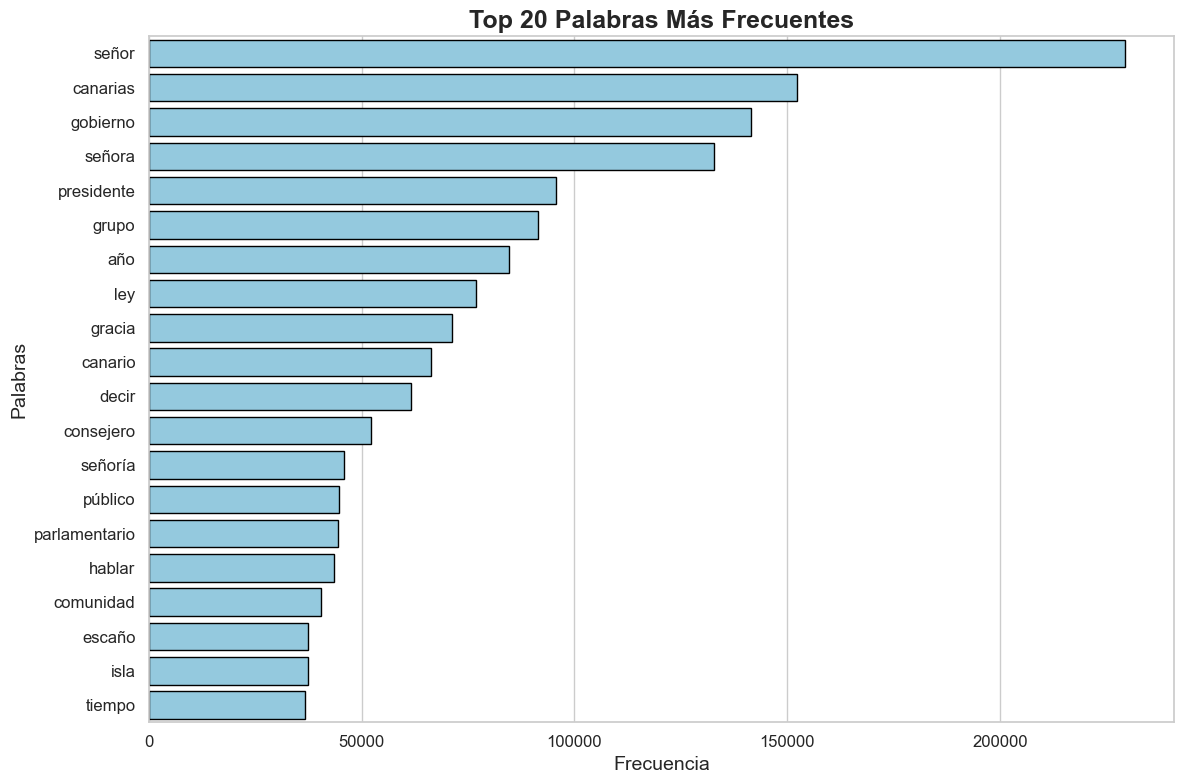

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=words, color='skyblue', edgecolor='black')

# Mejora visual de títulos y etiquetas
plt.title(f'Top {N} Palabras Más Frecuentes', fontsize=18, weight='bold')
plt.xlabel('Frecuencia', fontsize=14)
plt.ylabel('Palabras', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
def analyze_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0.1:
        return "Positivo"
    elif polarity < -0.1:
        return "Negativo"
    else:
        return "Neutral"


sentiments = [analyze_sentiment(text) for text in session_diaries]
sentiment_counts = Counter(sentiments)
sentiment_counts

Counter({'Neutral': 5728, 'Positivo': 4867, 'Negativo': 456})

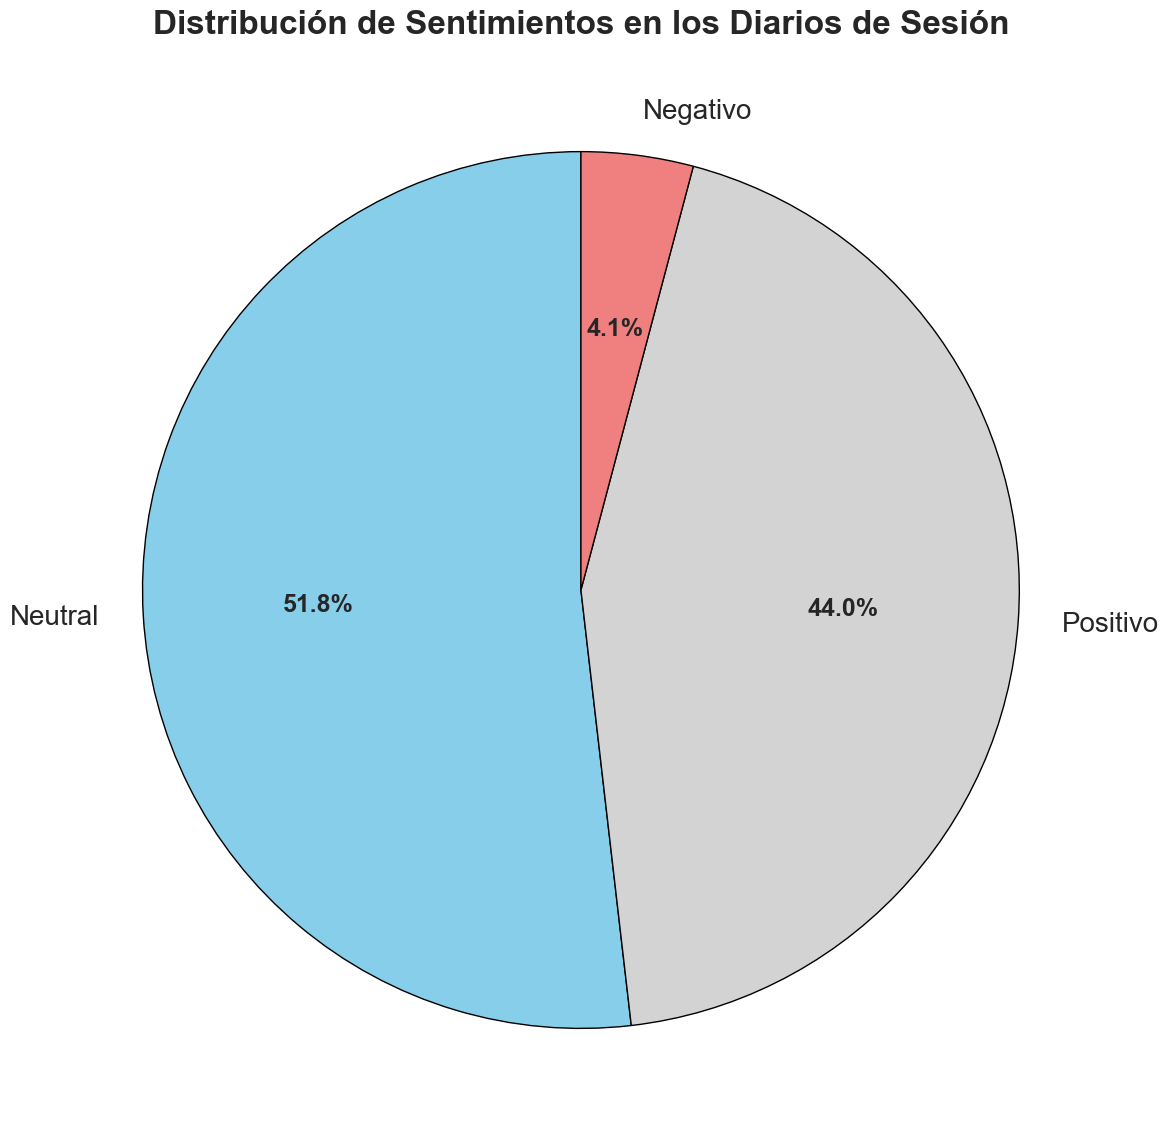

In [22]:
plt.figure(figsize=(12, 12))
wedges, texts, autotexts = plt.pie(
    sentiment_counts.values(),
    labels=sentiment_counts.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgray', 'lightcoral'],  # ajusta según tus categorías
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 20}  # etiquetas grandes
)

# Ajustamos los porcentajes dentro de la tarta
plt.setp(autotexts, size=18, weight='bold')

# Título más grande y en negrita
plt.title('Distribución de Sentimientos en los Diarios de Sesión', fontsize=24, weight='bold')

plt.tight_layout()
plt.show()